
## STOCHASTIC MODELING
MODULE 7 | LESSON 4


---

# **Real Networks**

|  |  |
|:---|:---|
|**Reading Time** |  60 minutes |
|**Prior Knowledge** | Random Networks, Erdos-Renyi model, Barabasi-Albert model  |
|**Keywords** | Network construction, Systemic risk


---

In the previous lesson, we explored how **scale-free structures** emerge endogenously through *preferential attachment* in the Barabási–Albert (BA) model. We learned that such networks are characterized by **heterogeneity**, **hubs**, and a **heavy-tailed degree distribution**, leading to both robustness and fragility.

In this lesson, we move from **theory to reality**.

Financial markets can also be viewed as complex networks — systems of assets, institutions, or contracts linked by dependence, ownership, or exposure. When market conditions are stable, these connections are relatively sparse: different assets move largely independently.  
But during financial stress, correlations tend to **rise sharply**, and the market becomes **tightly coupled**, allowing shocks to propagate more easily across the system.

Our goal is to use real data on U.S. equities to study these phenomena empirically, leveraging the BA framework we are already familiar with!


## **1. Getting and exploring the data**

We will work with very simple data: monthly returns of major 400 U.S. companies in the period 2005-2015. Let's quickly load the data to work with it!

In [1]:
import pandas as pd
returns = pd.read_csv("returns_2005_2015.csv", index_col=0, parse_dates=True)
returns.head()

,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Date,,,,,,,,,,,,,,,,,,,,,
2006-03-01,0.042154,-0.088007,-0.039474,0.020648,-0.082623,-0.098038,0.007098,0.062307,-0.011104,0.022845,...,0.046093,0.072558,-0.005240,0.066050,0.145406,-0.022338,0.030086,0.024028,-0.023104,0.013054
2006-04-01,0.022905,0.115371,0.006337,0.050817,-0.033821,0.114758,-0.009710,0.076906,-0.031606,0.087444,...,-0.012579,0.025591,0.032603,-0.027434,-0.009676,0.049072,0.035827,0.056111,-0.072062,-0.119322
2006-05-01,-0.096378,-0.163547,0.006082,-0.056723,-0.032160,-0.314222,-0.117091,0.134460,0.031047,-0.144328,...,-0.144493,-0.042403,-0.011446,-0.096929,-0.066687,-0.003723,-0.035006,-0.022668,-0.038076,-0.116933
2006-06-01,-0.100310,-0.042727,0.021087,0.035260,0.006021,0.058671,-0.043519,-0.004732,-0.002643,-0.054495,...,-0.059847,0.064318,-0.079323,-0.019867,0.029068,0.021608,0.012215,-0.002582,-0.065343,-0.033111
2006-07-01,-0.104094,0.171142,0.091111,0.023272,0.032653,-0.062871,0.005894,0.063812,-0.031633,-0.010209,...,-0.068364,0.067154,0.020622,-0.059401,-0.135521,0.055563,0.099082,-0.110747,0.108810,-0.085841


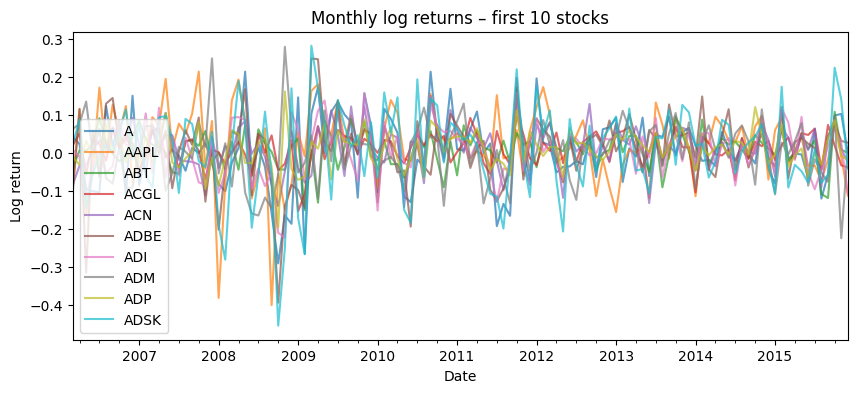

In [2]:
import matplotlib.pyplot as plt
returns.iloc[:, :10].plot(figsize=(10,4), alpha=0.7)
plt.title("Monthly log returns – first 10 stocks")
plt.xlabel("Date")
plt.ylabel("Log return")
plt.show()

Our data sample covers three key market regimes:

- **Pre-crisis (2005–2007)** — a relatively calm, stable period.  
- **Crisis (2008–2009)** — the Global Financial Crisis, characterized by sharp market-wide co-movements.  
- **Post-crisis (2010–2015)** — partial recovery and normalization.

Our main conjecture here is that stock's correlations are time-varying:

- In tranquil periods, correlations tend to be low and dispersed — assets move more independently.  
- In crises, correlations surge across the market — assets move together, reflecting systemic risk and reduced diversification.  

This “correlation contagion” can be represented as a **network**, where:
- **Nodes** are assets (stocks), and  
- **Edges** connect pairs of assets with correlations above a certain threshold.  

This transformation allows us to study **market structure, hubs, and fragility** through the lens of network theory.

We can observe this briefly with sample correlations:

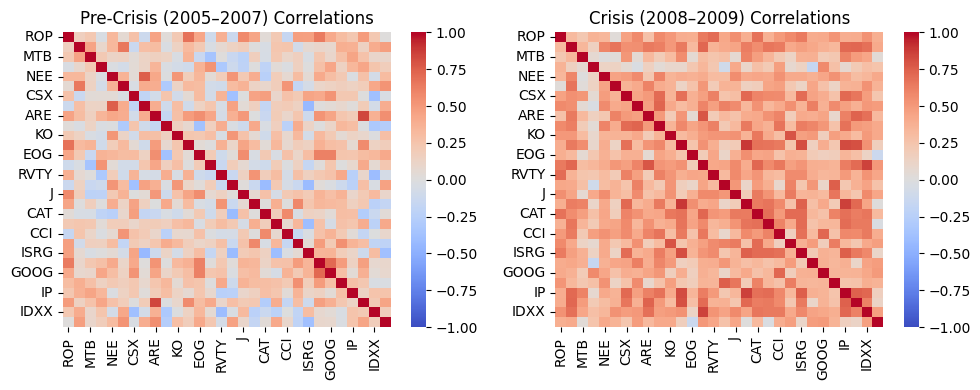

In [3]:
import seaborn as sns
import numpy as np


pre_crisis = returns.loc["2005":"2007"]
crisis     = returns.loc["2008":"2009"]

corr_pre = pre_crisis.corr()
corr_cri = crisis.corr()

# Select a random subset of 30 stocks to make plots readable
subset = np.random.choice(returns.columns, 30, replace=False)
corr_pre_sub = corr_pre.loc[subset, subset]
corr_cri_sub = corr_cri.loc[subset, subset]

# Correlation heatmaps
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(corr_pre_sub, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax[0])
ax[0].set_title("Pre-Crisis (2005–2007) Correlations")

sns.heatmap(corr_cri_sub, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax[1])
ax[1].set_title("Crisis (2008–2009) Correlations")

plt.tight_layout()
plt.show()

## **2. Building the Network**

To analyze market connectivity, we transform the **correlation matrix** into a **network representation**.

- **Nodes:** individual stocks  
- **Edges:** connections between pairs of stocks with sufficiently high correlation (e.g.,  $\rho_{ij} > 0.6 $)  
- **Edge weight:** the strength of the correlation itself

This way, we can study the market as a **graph of dependencies**, where denser and more clustered structures indicate stronger systemic coupling.

We will, therefore, build two networks:
- One for the **pre-crisis period** (2005–2007)  
- One for the **crisis period** (2008–2009)

and then compare their density, degree distribution, and overall structure.

In principle, we should expect the **crisis network** to be much denser — confirming that assets become more tightly linked during stress periods.

In [4]:
import networkx as nx

threshold = 0.4  # correlation threshold

# --- Correlation network ---
def build_corr_network(corr_matrix, threshold=threshold):
    G = nx.Graph()
    for i in corr_matrix.columns:
        G.add_node(i)
    # Add edges where correlation > threshold
    for i in corr_matrix.columns:
        for j in corr_matrix.columns:
            if i != j and corr_matrix.loc[i, j] > threshold:
                G.add_edge(i, j, weight=corr_matrix.loc[i, j])
    return G

G_pre = build_corr_network(corr_pre, threshold)
G_cri = build_corr_network(corr_cri, threshold)

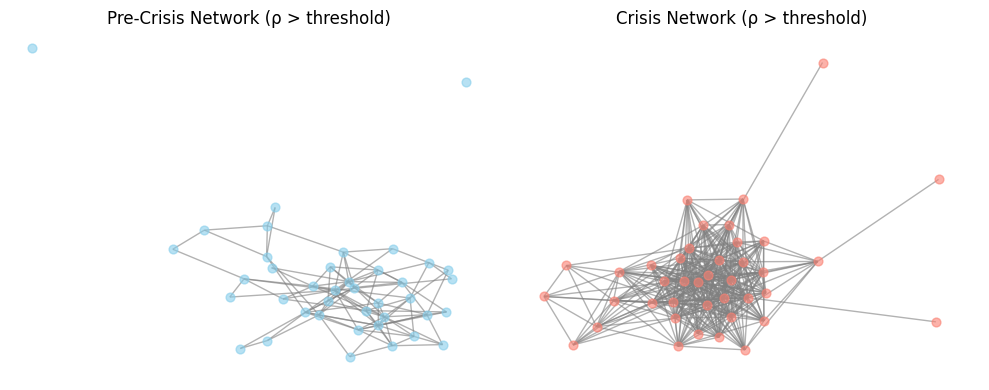

In [5]:
plt.figure(figsize=(10, 4))

subset_nodes = np.random.choice(list(G_pre.nodes()), 40, replace=False)
G_pre_sub = G_pre.subgraph(subset_nodes)
G_cri_sub = G_cri.subgraph(subset_nodes)

plt.subplot(1, 2, 1)
pos_pre = nx.spring_layout(G_pre_sub, seed=42)
nx.draw(G_pre_sub, pos_pre, node_size=40, node_color="skyblue", edge_color="gray", alpha=0.6)
plt.title("Pre-Crisis Network (ρ > threshold)")

plt.subplot(1, 2, 2)
pos_cri = nx.spring_layout(G_cri_sub, seed=42)
nx.draw(G_cri_sub, pos_cri, node_size=40, node_color="salmon", edge_color="gray", alpha=0.6)
plt.title("Crisis Network (ρ > threshold)")

plt.tight_layout()
plt.show()


In [6]:
# --- Basic metrics ---
def summarize_network(G, label):
    n, e = G.number_of_nodes(), G.number_of_edges()
    density = nx.density(G)
    degrees = [d for _, d in G.degree()]
    avg_deg = np.mean(degrees)
    print(f"{label} Network: {n} nodes, {e} edges")
    print(f"Average degree: {avg_deg:.2f} | Density: {density:.4f}")
    print("-"*50)

summarize_network(G_pre, "Pre-crisis (2005–2007)")
summarize_network(G_cri, "Crisis (2008–2009)")

Pre-crisis (2005–2007) Network: 401 nodes, 10637 edges
Average degree: 53.05 | Density: 0.1326
--------------------------------------------------
Crisis (2008–2009) Network: 401 nodes, 43289 edges
Average degree: 215.91 | Density: 0.5398
--------------------------------------------------


**How can we interpret these findings?**

- The **crisis network** is substantially denser than the pre-crisis one.  
  Almost all nodes are connected through strong correlations, reflecting market-wide synchronization.
- The **average degree** increases sharply — meaning each stock co-moves with more peers.
- In tranquil periods, the network is sparse, fragmented, and often disconnected, implying higher diversification potential.

## **3. Identifying hubs and systemic assets**

In a correlation network, each node’s **degree** measures how many other assets it is strongly connected to.  
A stock with high degree (or centrality) co-moves with many others — it acts as a **market hub**.

In this context, hubs are important because:

- They can **amplify shocks** — price movements in highly connected assets propagate through the network.
- They represent **systemically important assets or sectors** — central to market dynamics.
- In crises, they often correspond to **large financial institutions**, reflecting their exposure to market-wide risk.

We will use two complementary centrality measures:

1. **Degree centrality:** number of edges per node (normalized).  
   → captures *how many* other nodes a stock is linked to.

$$
C_D(i) = \frac{k_i}{N-1}
$$

where:
- $k_i$ is the degree of node $i$ (number of connections), and  
- $N$ is the total number of nodes.

Thus, $C_D(i) \in [0, 1]$, representing the fraction of possible connections that node $i$ actually has. In a **correlation network**, high $C_D(i)$ means the stock co-moves strongly with many others.
   
\
2. **Eigenvector centrality:** accounts for *who* you are connected to — nodes connected to other highly connected nodes get higher scores.  
   → captures *influence within the network*.

It is defined as the solution to:

$$
\mathbf{A} \mathbf{x} = \lambda \mathbf{x}
$$

where:
- $\mathbf{A}$ is the adjacency (or weighted correlation) matrix,  
- $\mathbf{x}$ is the vector of centralities, and  
- $\lambda$ is the largest eigenvalue of $\mathbf{A}$.

In component form:

$$
C_E(i) = \frac{1}{\lambda} \sum_{j} A_{ij} \, C_E(j)
$$

This recursive definition means a node’s centrality increases when it is connected to other central nodes.



\
By comparing these between pre-crisis and crisis periods, we can see how the market’s structural hierarchy changes under stress.


In [7]:
# --- Compute centralities ---
deg_pre = nx.degree_centrality(G_pre)
deg_cri = nx.degree_centrality(G_cri)

eig_pre = nx.eigenvector_centrality_numpy(G_pre, weight='weight')
eig_cri = nx.eigenvector_centrality_numpy(G_cri, weight='weight')

In [8]:
# --- Identifying top hubs ---
centrality_df = pd.DataFrame({
    'degree_pre': deg_pre,
    'degree_cri': deg_cri,
    'eigen_pre': eig_pre,
    'eigen_cri': eig_cri
}).fillna(0)

top_hubs_pre = centrality_df.sort_values('degree_pre', ascending=False).head(25)
display(top_hubs_pre)

,degree_pre,degree_cri,eigen_pre,eigen_cri
GS,0.3500,0.6400,0.123395,0.054081
HAS,0.3475,0.6800,0.125172,0.058324
AMP,0.3450,0.7750,0.120578,0.073841
TMO,0.3275,0.5400,0.116376,0.041606
SWK,0.3200,0.7775,0.120776,0.072027
YUM,0.2975,0.7425,0.101775,0.067278
MS,0.2950,0.3650,0.112610,0.026853
EQR,0.2925,0.6725,0.123644,0.064104
AVB,0.2900,0.7925,0.124666,0.076321
RJF,0.2875,0.3200,0.110353,0.022191


The previous table depicts the top 25 **hubs** just **before the crisis**. It is to no-one's surprise that we find a bunch of **financial institutions** (e.g., Goldman Sachs, Morgan Stanley, JP Morgan, Ameriprise); **insurance companies** (e.g., AIG, Metlife); and **real estate** trusts (Equity Residential, AvalonBay, Digital Realty, ...). 

These were actually the sectors that were most affected by the subprime collapse of 2008 and subsequent financial crisis. The data pre-crisis give us a good estimate of the weight in the overall economy (network) that these companies had, probably an early warning sign. 

In the mid-2000s, financial, insurance, and real estate (FIRE) firms were extremely central in the market network. Their stock returns co-moved with a wide range of sectors because of:

- Credit and mortgage exposure,
- Financial intermediation links,
- Investor sentiment spillovers.

When the housing and credit bubble burst, those same central hubs — large banks, insurers, and mortgage-related firms — experienced the largest drawdowns. Their losses propagated widely because they sat at the core of the correlation (and exposure) network.

\
**What about during the crisis?**

In [9]:
top_hubs_cri = centrality_df.sort_values('degree_cri', ascending=False).head(25)
display(top_hubs_cri)

,degree_pre,degree_cri,eigen_pre,eigen_cri
DOV,0.0700,0.8600,0.010050,0.077437
IVZ,0.1000,0.8600,0.026312,0.074870
RL,0.1075,0.8450,0.028294,0.077523
ADBE,0.1550,0.8425,0.047798,0.077729
ADSK,0.2425,0.8400,0.076044,0.075782
L,0.1925,0.8325,0.067836,0.073727
BEN,0.1900,0.8300,0.062396,0.072146
IEX,0.1575,0.8250,0.046748,0.074449
HON,0.1675,0.8250,0.043154,0.077003
DE,0.0875,0.8250,0.021555,0.072653


As you can see, a different picture emerges when we analyze the crisis period, where the storm already unveiled.

## **4. Performance of a hub portfolio**

We have identified the **top 25 stocks by degree centrality** in the **pre-crisis network** (2005–2007).  
These stocks represent the **market hubs** — firms that were strongly connected to many others, often in financial and real estate sectors.

To test whether stocks that were central hubs before the crisis suffered the most during the crisis period, we will analyze the performance of a **hub portfolio** (top 25 most central stocks) versus a **control portfolio:** of 25 randomly chosen non-hub stocks during the crisis.


In [15]:
crisis_returns = returns.loc["2008":"2009"]

# --- Hub stocks and control groups ---
hubs = top_hubs_pre.index.tolist()  
non_hubs = [x for x in returns.columns if x not in hubs]
np.random.seed(2)
control = np.random.choice(non_hubs, 25, replace=True)

print(f"Number of hub stocks: {len(hubs)}")
print(f"Number of control stocks: {len(control)}")

Number of hub stocks: 25
Number of control stocks: 25


In [16]:
# --- Compute cumulative returns over crisis period ---
cumret = (1 + crisis_returns).cumprod() - 1
hub_perf = cumret[hubs].mean(axis=1)
control_perf = cumret[control].mean(axis=1)

# --- Summary statistics ---
final_hub = hub_perf.iloc[-1]
final_ctrl = control_perf.iloc[-1]
print(f"Total cumulative return (2008–2009):")
print(f"Hub portfolio:     {final_hub:.2%}")
print(f"Control portfolio: {final_ctrl:.2%}")

Total cumulative return (2008–2009):
Hub portfolio:     -31.33%
Control portfolio: -18.64%


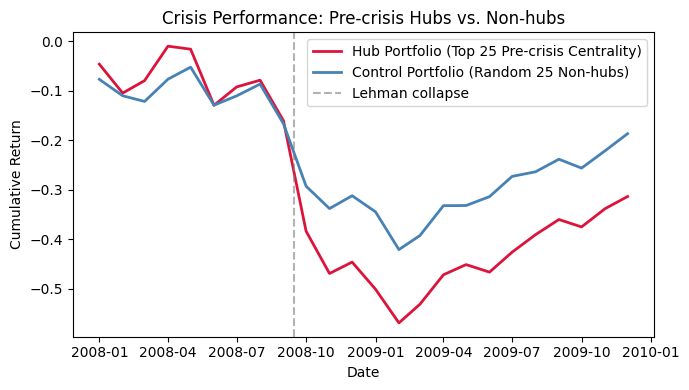

In [17]:
# --- Plot portfolio performance ---
plt.figure(figsize=(7,4))
plt.plot(hub_perf, label="Hub Portfolio (Top 25 Pre-crisis Centrality)", color="crimson", linewidth=2)
plt.plot(control_perf, label="Control Portfolio (Random 25 Non-hubs)", color="steelblue", linewidth=2)
plt.axvline(pd.Timestamp("2008-09-15"), color="gray", linestyle="--", alpha=0.6, label="Lehman collapse")
plt.title("Crisis Performance: Pre-crisis Hubs vs. Non-hubs")
plt.ylabel("Cumulative Return")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

It seems that firms that were most central before the crisis were also the most exposed when it hit. Their high centrality reflected not just influence, but systemic vulnerability.

Economically, this result can be interpreted as evidence that **excessive interconnectedness and market dominance can amplify downside risk** during systemic shocks — the “too-connected-to-fail” phenomenon.

## **5. Propagation of shocks**

Finally, we can use the network we built based on the data to simulate how the propagation of a shock affecting a hub will damage other nodes of the economy. The idea is to treat the correlation network as a conduit for distress. In the following code we will:

1. Pick a **hub node** (e.g., highest degree centrality in the pre-crisis network).
2. Apply an **initial shock** $\mathbf{d}^{(0)}$ (e.g., 10% distress) to that hub.
3. Propagate distress through neighbors using a **row-normalized weight matrix** $W$ and a **decay/contagion parameter** $\gamma \in (0,1)$:
   $$
   \mathbf{d}^{(t+1)} = \gamma \, W \, \mathbf{d}^{(t)}, \qquad
   \mathbf{L}^{(t+1)} = \mathbf{L}^{(t)} + \mathbf{d}^{(t+1)}
   $$
   where $\mathbf{L}^{(t)}$ is **cumulative** distress up to step $t$.
   
4. Stop after a fixed number of steps.

\
In this setting,

- $\gamma$ controls how much distress transmits per step (market tightness).  
- $W$ carries the **pattern of co-movement** (who affects whom).  
- The **shape** of $\mathbf{L}$ reveals which nodes/sectors are most exposed to the hub.

We will focus more on detail on all these features in future courses. For now, let's simply illustrate how we can leverage networks to simulate the incidence of systemic shocks.

In [60]:
# Pick a hub (highest degree centrality in crisis)
hub = max(deg_pre, key=deg_pre.get)
print(f"Shocking hub: {hub}")

Shocking hub: GS


In [61]:
# Build a weighted adjacency 
nodes = list(G_cri.nodes())
idx = {n: i for i, n in enumerate(nodes)}
n = len(nodes)

A = np.zeros((n, n))
for u, v, data in G_cri.edges(data=True):
    w = data.get("weight", 0.0)
    w_eff = max(w, 0.0)
    A[idx[u], idx[v]] = w_eff
    A[idx[v], idx[u]] = w_eff

In [62]:
# Row-normalize to get W
row_sums = A.sum(axis=1, keepdims=True)
W = np.divide(A, np.where(row_sums == 0, 1, row_sums), where=row_sums!=0)

In [74]:
# Set initial shock vector (% distress at the hub)
d = np.zeros(n)
d[idx[hub]] = 0.50 
L = d.copy()

In [78]:
# Iterate propagation
gamma = 0.99   # contagion/decay parameter 
max_steps = 25   # Iterate over 25 steps or when a increments are smaller than tolerance level
tol = 1e-5

total_distress = [L.sum()]
for t in range(max_steps):
    d_next = gamma * (W @ d)
    if np.linalg.norm(d_next, 1) < tol:
        break
    L += d_next
    d = d_next
    total_distress.append(L.sum())

print(f"Iterations: {len(total_distress)-1}, Total systemic distress: {total_distress[-1]:.4f}")

Iterations: 25, Total systemic distress: 6.2776


In [79]:
# What are the top impacted firms?
impacted = pd.Series(L, index=nodes).sort_values(ascending=False)
display(impacted.head(10))

GS      0.513889
CF      0.020479
AKAM    0.019807
EW      0.019233
VTRS    0.019176
BKNG    0.019138
SWKS    0.018999
TJX     0.018753
MOS     0.018652
BALL    0.018501
dtype: float64

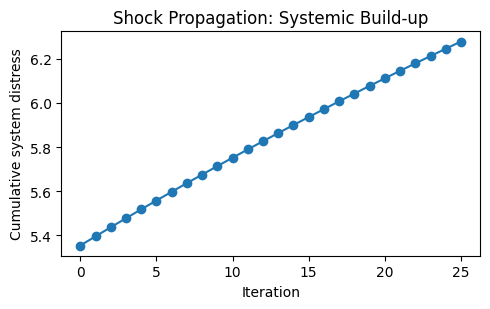

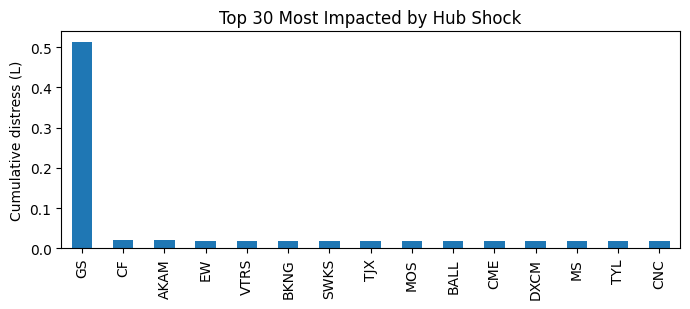

In [80]:
plt.figure(figsize=(5,3.2))
plt.plot(total_distress, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Cumulative system distress")
plt.title("Shock Propagation: Systemic Build-up")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,3.2))
impacted.head(15).plot(kind='bar')
plt.ylabel("Cumulative distress (L)")
plt.title("Top 30 Most Impacted by Hub Shock")
plt.tight_layout()
plt.show()

Now, this is a first exploration of how networks can be useful to simulate events. In this simple case, a shock to Goldman Sachs, GS, results in a bunch of firms being heavily impacted. Feel free to play around with the parameters, including gamma $\gamma$, to see how lower / higher values result in different speeds of shock propagation. Likewise, you can play with the number of steps to see which firms would be impacted sooner. 

## **6. Conclusion**

Good job reaching the end of the Module! In this module we have introduced some basic concepts of Graph and Network theory, and see their real life applicability in a setting of stock correlations. 

This is all for the Stochastic Modeling course!

---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
